In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('../data/raw/najeemetal25.csv')

In [3]:
df.head()

,StudyHours,Attendance,Resources,Extracurricular,Motivation,Internet,Gender,Age,LearningStyle,OnlineCourses,Discussions,AssignmentCompletion,ExamScore,EduTech,StressLevel,FinalGrade
0,19,64,1,0,0,1,0,19,2,8,1,59,40,0,1,3
1,19,64,1,0,0,1,0,23,3,16,0,90,66,0,1,2
2,19,64,1,0,0,1,0,28,1,19,0,67,99,1,1,0
3,19,64,1,1,0,1,0,19,2,8,1,59,40,0,1,3
4,19,64,1,1,0,1,0,23,3,16,0,90,66,0,1,2


In [4]:
print(f"dataset shape: {df.shape}")
print(f"dataset shape: {df.shape[0]:,}")
print(f"number of variables: {df.shape[1]}")

dataset shape: (14003, 16)
dataset shape: 14,003
number of variables: 16


In [5]:
print ("column names and data types:")
print(df.dtypes)
print("\n" + "="*50 + "\n")
print("column names list:")
print(df.columns.tolist())

column names and data types:
StudyHours              int64
Attendance              int64
Resources               int64
Extracurricular         int64
Motivation              int64
Internet                int64
Gender                  int64
Age                     int64
LearningStyle           int64
OnlineCourses           int64
Discussions             int64
AssignmentCompletion    int64
ExamScore               int64
EduTech                 int64
StressLevel             int64
FinalGrade              int64
dtype: object


column names list:
['StudyHours', 'Attendance', 'Resources', 'Extracurricular', 'Motivation', 'Internet', 'Gender', 'Age', 'LearningStyle', 'OnlineCourses', 'Discussions', 'AssignmentCompletion', 'ExamScore', 'EduTech', 'StressLevel', 'FinalGrade']


In [6]:
df.describe()

,StudyHours,Attendance,Resources,Extracurricular,Motivation,Internet,Gender,Age,LearningStyle,OnlineCourses,Discussions,AssignmentCompletion,ExamScore,EduTech,StressLevel,FinalGrade
count,14003.000000,14003.000000,14003.000000,14003.000000,14003.000000,14003.000000,14003.000000,14003.000000,14003.000000,14003.000000,14003.00000,14003.000000,14003.000000,14003.000000,14003.000000,14003.000000
mean,19.987431,80.194316,1.104406,0.594158,0.905806,0.925516,0.551953,23.532172,1.515461,9.891952,0.60587,74.502535,70.346926,0.709062,1.304363,1.447904
std,5.890637,11.472181,0.697362,0.491072,0.695896,0.262566,0.497311,3.514293,1.112941,6.112801,0.48868,14.632177,17.688113,0.454211,0.785383,1.121550
min,5.000000,60.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.000000,0.000000,0.000000,0.00000,50.000000,40.000000,0.000000,0.000000,0.000000
25%,16.000000,70.000000,1.000000,0.000000,0.000000,1.000000,0.000000,20.000000,1.000000,5.000000,0.00000,62.000000,55.000000,0.000000,1.000000,0.000000
50%,20.000000,80.000000,1.000000,1.000000,1.000000,1.000000,1.000000,24.000000,2.000000,10.000000,1.00000,74.000000,70.000000,1.000000,2.000000,1.000000
75%,24.000000,90.000000,2.000000,1.000000,1.000000,1.000000,1.000000,27.000000,3.000000,15.000000,1.00000,87.000000,86.000000,1.000000,2.000000,2.000000
max,44.000000,100.000000,2.000000,1.000000,2.000000,1.000000,1.000000,29.000000,3.000000,20.000000,1.00000,100.000000,100.000000,1.000000,2.000000,3.000000


In [7]:
print("missing values per column:")
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100

missing_summary = pd.DataFrame({
    'Missing_Count': missing,
    'Percentage': missing_pct})

print(missing_summary[missing_summary['Missing_Count'] > 0])

if missing.sum() == 0:
    print("\n no_missing_values_in_dataset.")

missing values per column:
Empty DataFrame
Columns: [Missing_Count, Percentage]
Index: []

 no_missing_values_in_dataset.


In [8]:
duplicates = df.duplicated().sum()
print(f"number_of_duplicate_rows: {duplicates}")

if duplicates > 0:
    print(f"percentage_of_duplicates: {(duplicates/len(df)*100):.2f}%")
else:
    print("no_duplicate_rows_found")

number_of_duplicate_rows: 1534
percentage_of_duplicates: 10.95%


In [9]:
print("="*50)
print("STRESS LEVEL ANALYSIS")
print("="*50)
print(f"\nMean Stress: {df['StressLevel'].mean():.2f}")
print(f"Median Stress: {df['StressLevel'].median():.2f}")
print(f"Std Dev: {df['StressLevel'].std():.2f}")
print(f"Min Stress: {df['StressLevel'].min()}")
print(f"Max Stress: {df['StressLevel'].max()}")

print("\nStress Level Distribution:")
print(df['StressLevel'].value_counts().sort_index().head(20))


STRESS LEVEL ANALYSIS

Mean Stress: 1.30
Median Stress: 2.00
Std Dev: 0.79
Min Stress: 0
Max Stress: 2

Stress Level Distribution:
StressLevel
0    2836
1    4069
2    7098
Name: count, dtype: int64


In [10]:
print("="*50)
print("EXAM SCORE ANALYSIS")
print("="*50)
print(f"\nMean Score: {df['ExamScore'].mean():.2f}")
print(f"Median Score: {df['ExamScore'].median():.2f}")
print(f"Std Dev: {df['ExamScore'].std():.2f}")
print(f"Min Score: {df['ExamScore'].min()}")
print(f"Max Score: {df['ExamScore'].max()}")

print("\nScore distribution (in 10-point bins):")
bins = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
df['ScoreBin'] = pd.cut(df['ExamScore'], bins=bins)
print(df['ScoreBin'].value_counts().sort_index())
df = df.drop('ScoreBin', axis=1)

EXAM SCORE ANALYSIS

Mean Score: 70.35
Median Score: 70.00
Std Dev: 17.69
Min Score: 40
Max Score: 100

Score distribution (in 10-point bins):
ScoreBin
(0, 10]         0
(10, 20]        0
(20, 30]        0
(30, 40]      203
(40, 50]     2267
(50, 60]     2197
(60, 70]     2399
(70, 80]     2159
(80, 90]     2380
(90, 100]    2398
Name: count, dtype: int64


In [11]:
print("="*50)
print("CATEGORICAL VALUES")
print("="*50)

categorical_cols = df.select_dtypes(exclude='number').columns

for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].value_counts())
    print("-"*30)

CATEGORICAL VALUES


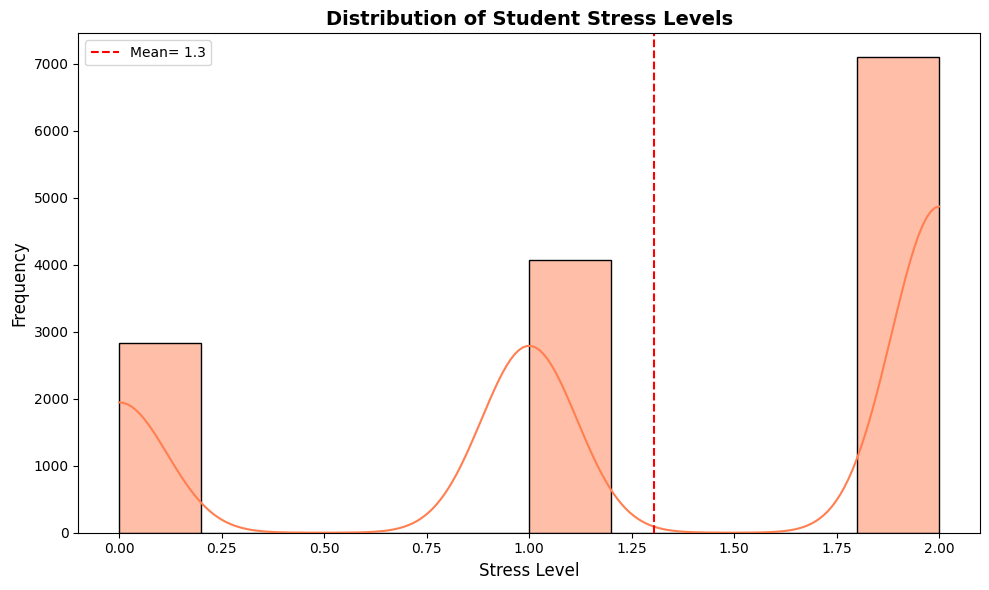

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.histplot(df['StressLevel'], bins=10, kde=True, color='coral')
plt.title('Distribution of Student Stress Levels', fontsize=14, fontweight='bold')
plt.xlabel ('Stress Level', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.axvline(df['StressLevel'].mean(), color='red', linestyle='--', label=f'Mean= {df["StressLevel"].mean():.1f}')
plt.legend()
plt.tight_layout()
plt.show()
                       

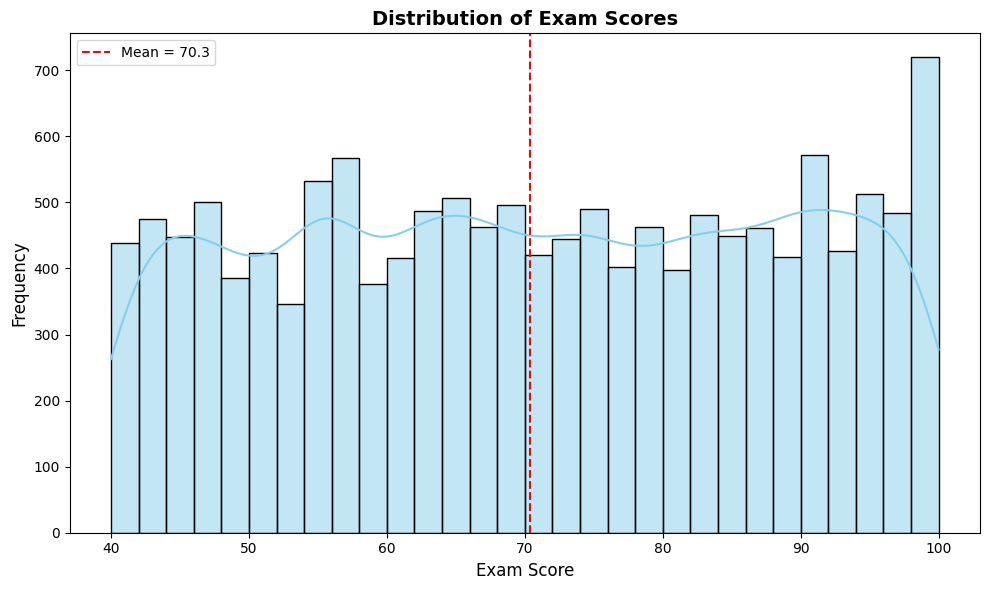

In [13]:
plt.figure(figsize=(10, 6))
sns.histplot(df['ExamScore'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of Exam Scores', fontsize=14, fontweight='bold')
plt.xlabel('Exam Score', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.axvline(df['ExamScore'].mean(), color='red', linestyle='--', label=f'Mean = {df["ExamScore"].mean():.1f}')
plt.legend()
plt.tight_layout()
plt.show()

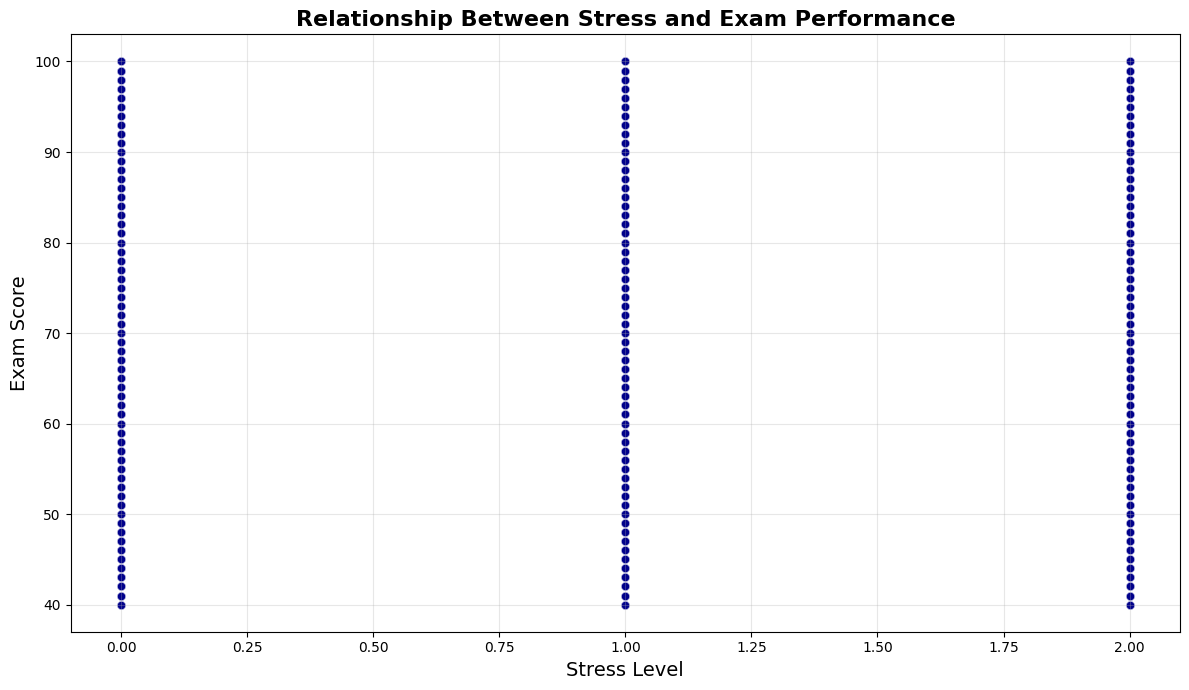

In [14]:
plt.figure(figsize=(12, 7))
sns.scatterplot(data=df, x='StressLevel', y='ExamScore', alpha=.5, color='darkblue')
plt.title('Relationship Between Stress and Exam Performance', fontsize=16, fontweight='bold')
plt.xlabel('Stress Level', fontsize=14)
plt.ylabel('Exam Score', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [15]:
correlation = df['StressLevel'].corr(df['ExamScore'])
print(f"Correlation between Stress and Exam Score: {correlation:.3f}")

if correlation < -0.3:
    print("Moderate to strong NEGATIVE relationship (more stress = lower scores)")
elif correlation < -0.1:
    print("Weak negative relationship")
elif correlation > 0.3:
    print("Moderate to strong POSITIVE relationship (more stress = higher scores)")
elif correlation > 0.1:
    print("Weak positive relationship")
else:
    print("Very weak or no linear relationship")

Correlation between Stress and Exam Score: -0.032
Very weak or no linear relationship


In [16]:
print("="*60)
print("INITIAL DATA EXPLORATION SUMMARY")
print("="*60)
print(f"\n Dataset Size: {df.shape[0]:,} students, {df.shape[1]} variables")
print(f"\nKey Statistics:")
print(f"Average Stress Level: {df['StressLevel'].mean():.2f}")
print(f"Average Exam Score: {df['ExamScore'].mean():.2f}")
print(f"Stress-Performance Correlation: {correlation:.3f}")
print(f"\n Data Quality:")
print(f"Missing Values: {df.isnull().sum().sum()}")
print(f"Duplicate Rows: {df.duplicated().sum()}")
print("\nNext Steps:")
print("1. Data cleaning")
print("2.Create stress categories")
print("3.Deeper Exploration with multiple variables")
print("4.Statistical testing")
print("="*60)

INITIAL DATA EXPLORATION SUMMARY

 Dataset Size: 14,003 students, 16 variables

Key Statistics:
Average Stress Level: 1.30
Average Exam Score: 70.35
Stress-Performance Correlation: -0.032

 Data Quality:
Missing Values: 0
Duplicate Rows: 1534

Next Steps:
1. Data cleaning
2.Create stress categories
3.Deeper Exploration with multiple variables
4.Statistical testing


In [17]:
print("Unique Stress Levels:")
print(sorted(df['StressLevel'].unique()))
print(f"\nValue counts:")
print(df['StressLevel'].value_counts().sort_index())

Unique Stress Levels:
[np.int64(0), np.int64(1), np.int64(2)]

Value counts:
StressLevel
0    2836
1    4069
2    7098
Name: count, dtype: int64


In [18]:
print("="*60)
print("STRESS LEVEL DEEP DIVE")
print("="*60)
print(f"\nUnique values: {sorted(df['StressLevel'].unique())}")
print(f"Number of unique values: {df['StressLevel'].nunique()}")
print("\nFrequency of each stress level:")
print(df['StressLevel'].value_counts().sort_index())
print("\nPercentage distribution:")
print((df['StressLevel'].value_counts(normalize=True).sort_index() * 100).round(2))

STRESS LEVEL DEEP DIVE

Unique values: [np.int64(0), np.int64(1), np.int64(2)]
Number of unique values: 3

Frequency of each stress level:
StressLevel
0    2836
1    4069
2    7098
Name: count, dtype: int64

Percentage distribution:
StressLevel
0    20.25
1    29.06
2    50.69
Name: proportion, dtype: float64


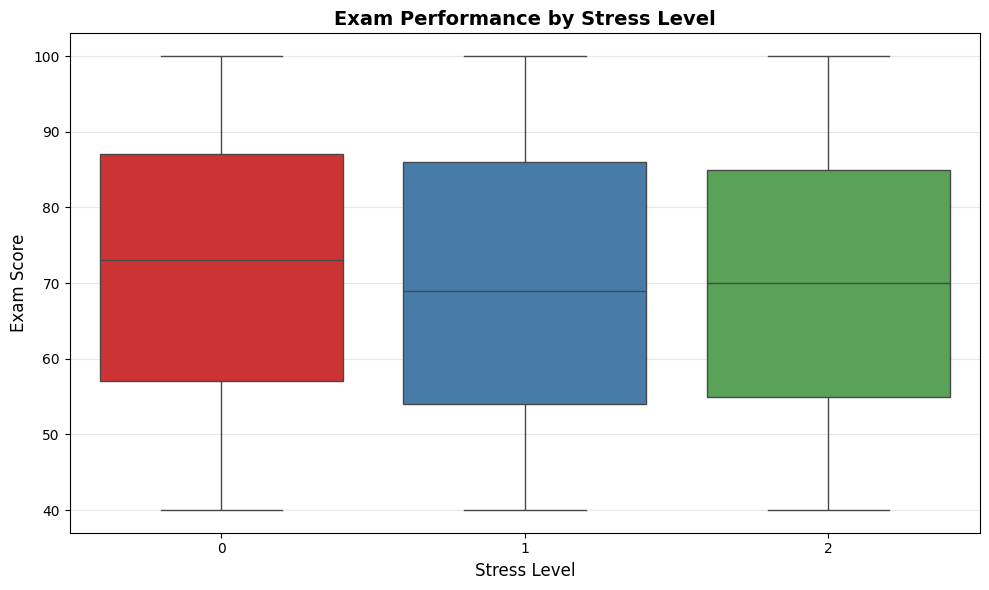


Mean Exam Score by Stress Level:
              mean    std  count
StressLevel                     
0            71.88  17.52   2836
1            69.75  17.84   4069
2            70.08  17.63   7098


In [19]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='StressLevel', y='ExamScore', hue='StressLevel', palette='Set1', legend=False)
plt.title('Exam Performance by Stress Level', fontsize=14, fontweight='bold')
plt.xlabel('Stress Level', fontsize=12)
plt.ylabel('Exam Score', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nMean Exam Score by Stress Level:")
print(df.groupby('StressLevel')['ExamScore'].agg(['mean', 'std', 'count']).round(2))

In [20]:
from scipy import stats

low_stress = df[df['StressLevel'] == 0]['ExamScore']
med_stress = df[df['StressLevel'] == 1]['ExamScore']
high_stress = df[df['StressLevel'] == 2]['ExamScore']

f_stat, p_value = stats.f_oneway(low_stress, med_stress, high_stress)

print("="*60)
print("ANOVA: Do stress levels significantly affect exam scores?")
print("="*60)
print(f"F-statistic: {f_stat:.3f}")
print(f"P-value: {p_value:.4f}")
print()

if p_value < 0.001:
    print("HIGHLY SIGNIFICANT (p < 0.001)")
    print("Stress level DOES significantly affect exam performance!")
elif p_value < 0.05:
    print("SIGNIFICANT (p < 0.05)")
    print("Stress level affects exam performance")
else:
    print("NOT SIGNIFICANT (p ≥ 0.05)")
    print("Differences could be due to random chance")

print()
print("Mean differences:")
print(f"Low vs Medium: {71.88 - 69.75:.2f} points")
print(f"Low vs High: {71.88 - 70.08:.2f} points")
print(f"Medium vs High: {69.75 - 70.08:.2f} points")

ANOVA: Do stress levels significantly affect exam scores?
F-statistic: 13.805
P-value: 0.0000

HIGHLY SIGNIFICANT (p < 0.001)
Stress level DOES significantly affect exam performance!

Mean differences:
Low vs Medium: 2.13 points
Low vs High: 1.80 points
Medium vs High: -0.33 points


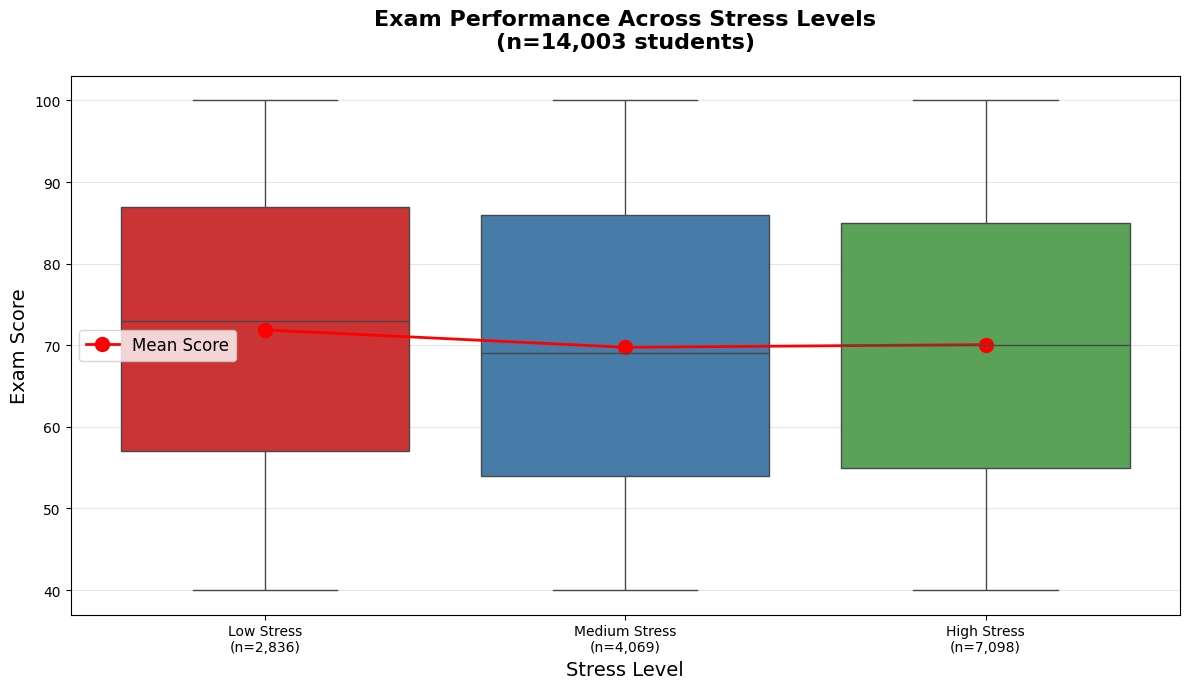


Summary Statistics by Stress Level:
              mean  median    std  min  max
StressLevel                                
0            71.88    73.0  17.52   40  100
1            69.75    69.0  17.84   40  100
2            70.08    70.0  17.63   40  100


In [21]:
plt.figure(figsize=(12,7))

bp = sns.boxplot(data=df, x='StressLevel', y='ExamScore', hue='StressLevel', palette='Set1', legend=False)

means = df.groupby('StressLevel')['ExamScore'].mean()
positions = range(len(means))
plt.plot(positions, means, 'ro-', linewidth=2, markersize=10, label='Mean Score')

plt.title('Exam Performance Across Stress Levels\n(n=14,003 students)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Stress Level', fontsize=14)
plt.ylabel('Exam Score', fontsize=14)

plt.xticks([0, 1, 2], ['Low Stress\n(n=2,836)', 'Medium Stress\n(n=4,069)', 'High Stress\n(n=7,098)'])

plt.legend(fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nSummary Statistics by Stress Level:")
summary = df.groupby('StressLevel')['ExamScore'].agg(['mean', 'median', 'std', 'min', 'max'])
print(summary.round(2))


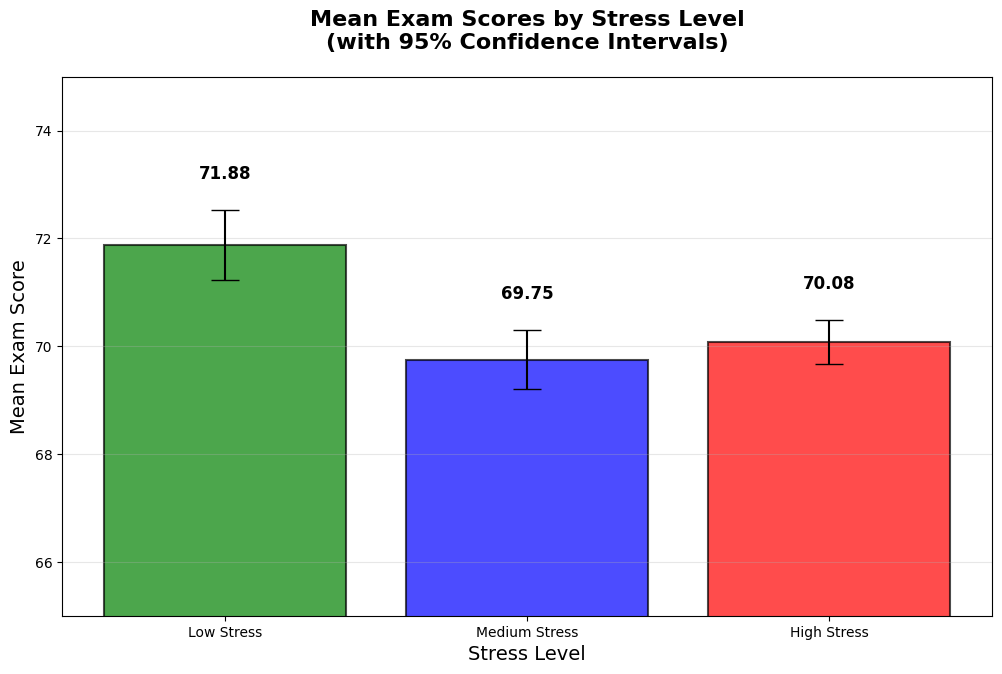

In [22]:
plt.figure(figsize=(12, 7))

stress_groups = df.groupby('StressLevel')['ExamScore'].agg(['mean', 'std', 'count'])
stress_groups['se'] = stress_groups['std'] / np.sqrt(stress_groups['count'])
stress_groups['ci95'] = 1.96 * stress_groups['se']

x_pos = [0, 1, 2]
plt.bar(x_pos, stress_groups['mean'], yerr=stress_groups['ci95'],alpha=0.7, color=['green', 'blue', 'red'], capsize=10, edgecolor='black', linewidth=1.5)

plt.title('Mean Exam Scores by Stress Level\n(with 95% Confidence Intervals)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Stress Level', fontsize=14)
plt.ylabel('Mean Exam Score', fontsize=14)
plt.xticks(x_pos, ['Low Stress', 'Medium Stress', 'High Stress'])
plt.ylim(65, 75)
plt.grid(axis='y', alpha=0.3)

for i, (mean, ci) in enumerate(zip(stress_groups['mean'], stress_groups['ci95'])):
    plt.text(i, mean + ci + 0.5, f'{mean:.2f}', ha='center', va='bottom', fontweight='bold', fontsize=12)

In [23]:
from scipy.stats import ttest_ind

print("="*60)
print("POST-HOC TESTS: Which pairs are significantly different?")
print("="*60)
print("\nBonferroni-corrected significance level: 0.05/3 = 0.0167")
print("(3 comparisons, so p < 0.0167 is required for significance)\n")

pairs = [("Low", "Medium", low_stress, med_stress),
         ("Low", "High", low_stress, high_stress),
         ("Medium", "High", med_stress, high_stress)]

for name1, name2, g1, g2 in pairs:
    t, p = ttest_ind(g1, g2)
    print(f"{name1} vs {name2} Stress:")
    print(f"  Mean difference: {g1.mean() - g2.mean():.2f} points")
    print(f"  t-statistic: {t:.3f}")
    print(f"  p-value: {p:.6f}")
    print(f"  {'SIGNIFICANT' if p < 0.0167 else 'Not significant'}\n")

print("="*60)

POST-HOC TESTS: Which pairs are significantly different?

Bonferroni-corrected significance level: 0.05/3 = 0.0167
(3 comparisons, so p < 0.0167 is required for significance)

Low vs Medium Stress:
  Mean difference: 2.13 points
  t-statistic: 4.912
  p-value: 0.000001
  SIGNIFICANT

Low vs High Stress:
  Mean difference: 1.80 points
  t-statistic: 4.610
  p-value: 0.000004
  SIGNIFICANT



Medium vs High Stress:
  Mean difference: -0.33 points
  t-statistic: -0.935
  p-value: 0.349687
  Not significant



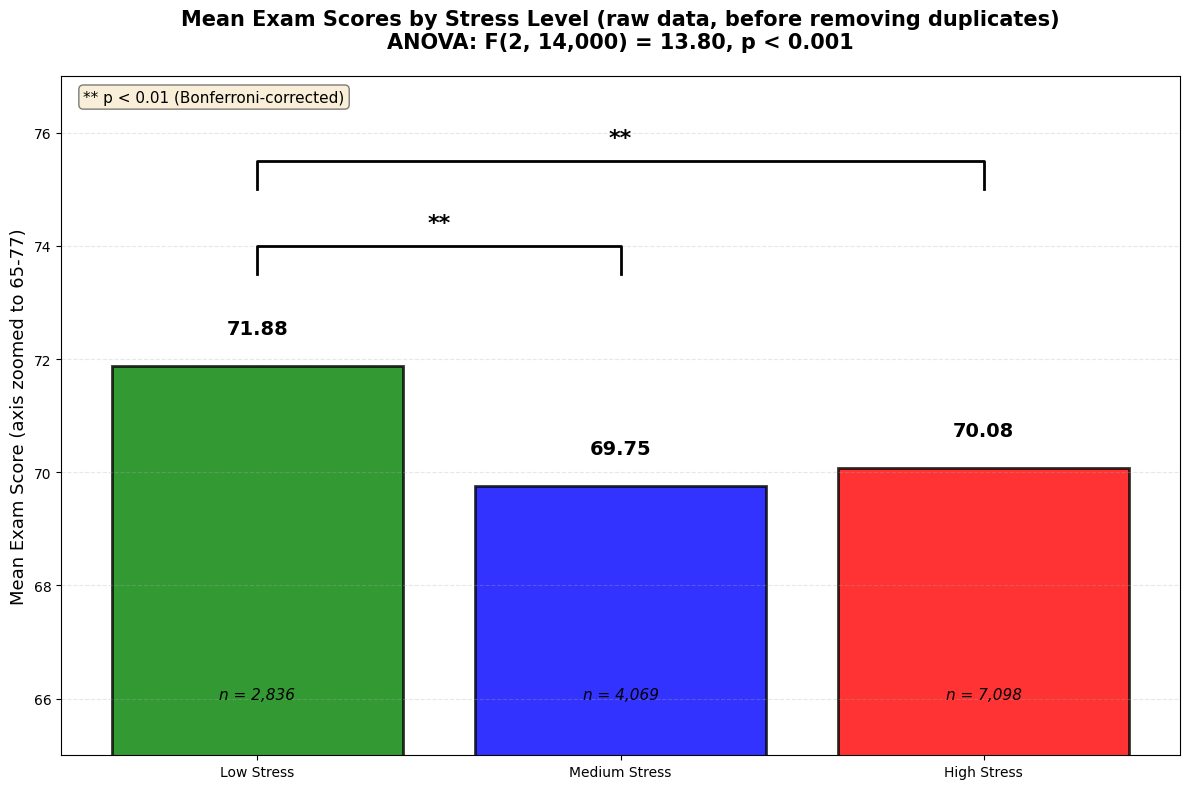

In [24]:
plt.figure(figsize=(12, 8))

stress_labels = ['Low Stress', 'Medium Stress', 'High Stress']
groups = [low_stress, med_stress, high_stress]
means = [g.mean() for g in groups]
counts = [len(g) for g in groups]
colors = ['green', 'blue', 'red']

bars = plt.bar(stress_labels, means, color=colors, alpha=0.8, edgecolor='black', linewidth=2)

for bar, mean in zip(bars, means):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5, f'{mean:.2f}',
             ha='center', va='bottom', fontweight='bold', fontsize=14)

plt.plot([0, 0, 1, 1], [73.5, 74, 74, 73.5], 'k-', linewidth=2)
plt.text(0.5, 74.3, '**', ha='center', fontsize=16, fontweight='bold')
plt.plot([0, 0, 2, 2], [75, 75.5, 75.5, 75], 'k-', linewidth=2)
plt.text(1, 75.8, '**', ha='center', fontsize=16, fontweight='bold')

plt.title(f'Mean Exam Scores by Stress Level (raw data, before removing duplicates)\n'
          f'ANOVA: F(2, {len(df) - 3:,}) = {f_stat:.2f}, p < 0.001', fontsize=15, fontweight='bold', pad=20)
plt.ylabel('Mean Exam Score (axis zoomed to 65-77)', fontsize=13)
plt.ylim(65, 77)
plt.grid(axis='y', alpha=0.3, linestyle='--')

for i, count in enumerate(counts):
    plt.text(i, 66, f'n = {count:,}', ha='center', fontsize=11, style='italic')

plt.text(0.02, 0.98, '** p < 0.01 (Bonferroni-corrected)', transform=plt.gca().transAxes,
         fontsize=11, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

# Preliminary chart only. The final figure (figures/stress_performance_main_finding.png)
# is created in 04_statistical_analysis.ipynb from the cleaned data.

## Preliminary Notes (raw data, before cleaning)

These results use all 14,003 raw records, including 1,534 duplicate rows that are removed in `02_data_cleaning.ipynb`. Final results come from the cleaned data in `04_statistical_analysis.ipynb`.

- **ANOVA:** F(2, 14000) = 13.81, p < .001
- **Low stress (0):** M = 71.88, SD = 17.52, n = 2,836
- **Medium stress (1):** M = 69.75, SD = 17.84, n = 4,069
- **High stress (2):** M = 70.08, SD = 17.63, n = 7,098
- **Pairwise tests:** low stress differs from both medium and high stress; medium and high do not differ from each other.
- **Correlation:** r = -0.03 between stress and exam score, so any relationship is very weak.

**Questions for the next notebooks:**
1. Does the pattern hold after removing duplicates?
2. How large is the effect, not just whether it is significant?
3. Do study hours, motivation, or demographics change the relationship?